# Interpolation

- Interpolation methods allow us to connect discrete data points.


- Interpolating data is NOT the same as carrying out a regression. Regressions need some physically-motivated model, interpolation methods do not care about any underlying physics, they just connect points with functions.


- When do we use interpolation? When we have incomplete data series (e.g. a temperature data series that has missing points because of e.g. instrument issues like a broken thermometer or so).


- Two types of interpolation exist:

**1) Global (single-function) interpolation**, in which all data points are connected by a single function, and 

**2) Point-to-point interpolation** where every pair of data points is connected with individual functions.


- In most situations in physics, we are more likely to use point-to-point interpolation, but it is useful to know how the methods in both cases work.

## I. Global interpolation:

Here, our job is to connect discrete data points with a single global function.



### 1. Newton interpolation

Please read the equations and code in this reference. The code below is based on the material given in this book:

https://pythonnumericalmethods.berkeley.edu/notebooks/chapter17.05-Newtons-Polynomial-Interpolation.html


In [1]:
# Importing libraries

import numpy as np
import matplotlib.pyplot as plt

### Example:

Find the polynomial function that goes through all the following data points:

$x= [-8,-5, -1, 0, 2, 4]$

$y= [-4,-2, 6, 1, 3, 5]$

In [2]:
# We need the vectors
x = np.array([-8,-5,-1,0,2,4])
y = np.array([-4,-2,6,1,3,5])

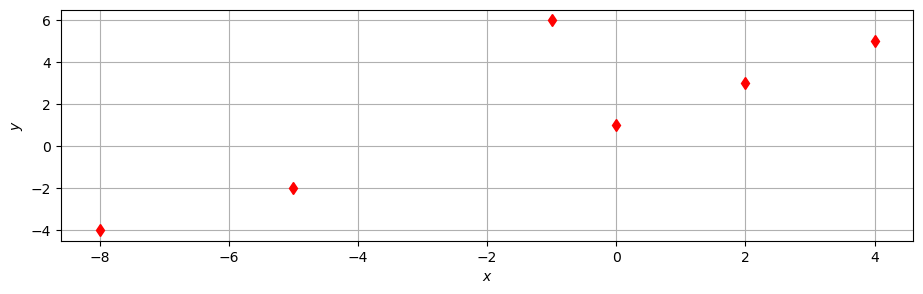

In [3]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(x, y, marker = "d", color = "red", linestyle = " ")
plt.grid()

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.show()

#### Constructing our own Newton interpolator.

We need 2 functions, one to compute the coefficient of the Newton polynomial and one evaluate it.

In [4]:
# Function for the divided differences

def div_diff(x_values, y_values):
    """
    This is function that computes the divided differences.
    Inputs: data vectors
    Outputs: coefficients of the polynomial
    """
    # We get the length of the vectors
    n = len(x_values)
    
    # We need an empty array to host the coefficients
    a_coef = np.zeros([n, n])
    
    # First we place the y values onto the 1st column
    a_coef[:,0] = y_values
    
    # We iterate obver the indices of the matrix
    for j in range(1, n):
        for i in range(n - j):
            
            a_coef[i][j] = (a_coef[i + 1][j - 1] - a_coef[i][j - 1]) / (x_values[i + j] - x_values[i])
        
    return a_coef

In [5]:
# Now we need a function to evalue the polynomial

def newton_polynomial(coef, x_values, x_new):
    """
    Function to evaluate the Newton polynomial at specific 
    x_new values (which are a new x axis)
    """
    n = len(x_values) - 1 
    newton = coef[n]
    
    for k in range(1, n + 1):
        newton = coef[n - k] + (x_new - x_values[n - k])*newton
    
    return newton


#### Calling our functions:

In [6]:
# First we get the coefficients

a_coef_matrix = div_diff(x, y)

print(a_coef_matrix)

[[-4.          0.66666667  0.19047619 -0.19880952  0.06845238 -0.01390542]
 [-2.          2.         -1.4         0.48571429 -0.0984127   0.        ]
 [ 6.         -5.          2.         -0.4         0.          0.        ]
 [ 1.          1.          0.          0.          0.          0.        ]
 [ 3.          1.          0.          0.          0.          0.        ]
 [ 5.          0.          0.          0.          0.          0.        ]]


In [7]:
# We want the first row:

a_coef1 = div_diff(x, y)[0,:]

print(a_coef1)

[-4.          0.66666667  0.19047619 -0.19880952  0.06845238 -0.01390542]


#### Evaluating the Newton polynomial:

In [8]:
# Now we call our Newton polynomial function

x_new1 = np.arange(-8., 4.1, 0.1)
y_new1 = newton_polynomial(a_coef1, x, x_new1)

#### Plotting the Newton polynomial interpolator:

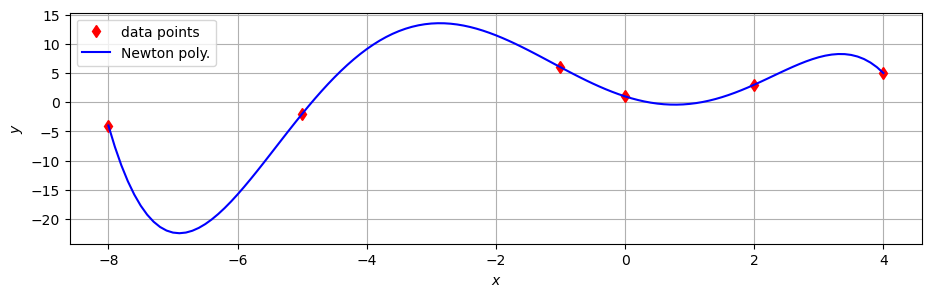

In [9]:
# Plotting the result

plt.figure(figsize=(11,3))

plt.plot(x, y, marker = "d", color = "red", linestyle = " "\
        , label = "data points")
plt.plot(x_new1, y_new1, color = "blue", linestyle = "-"\
        , label ="Newton poly.")

plt.grid()

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.legend()
plt.show()

### 2. Lagrange interpolation

We will use **scipy.interpolate.lagrange** for this. Please read the equations and underlying algorithm in the reference below:

https://pythonnumericalmethods.berkeley.edu/notebooks/chapter17.04-Lagrange-Polynomial-Interpolation.html

In [13]:
# Importing the scipy interpolators

import scipy.interpolate as interp

In [14]:
# Now we call the lagrange function

lagrange_poly = interp.lagrange(x, y)

print("The object type is: ", type(lagrange_poly))

print("\n")

print("The actual interpolator is:\n",lagrange_poly)

NameError: name 'x' is not defined

#### Evaluating the Lagrange function:

We can use Polynomial for this:

https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html

In [12]:
from numpy.polynomial.polynomial import Polynomial

In [13]:
# See only the coefficients

Polynomial(lagrange_poly.coef[::-1]).coef

array([ 1.        , -3.54351852,  1.95287698,  0.41188823, -0.0984127 ,
       -0.01390542])

In [15]:
# Get the y vector

y_new2 = Polynomial(lagrange_poly.coef[::-1])(x_new1)

print(y_new2.shape)

print(x_new1.shape, y_new2.shape)

(121,)
(121,) (121,)


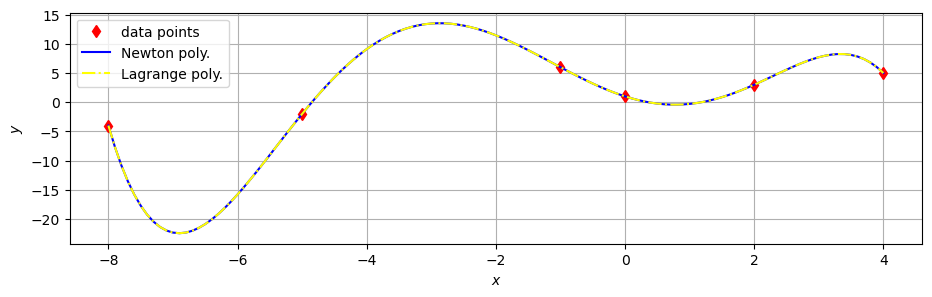

In [16]:
# Plotting the result

plt.figure(figsize=(11,3))

plt.plot(x, y, marker = "d", color = "red", linestyle = " "\
        , label = "data points")
plt.plot(x_new1, y_new1, color = "blue", linestyle = "-"\
        , label ="Newton poly.")
plt.plot(x_new1, y_new2, color = "yellow", linestyle = "-."\
        , label ="Lagrange poly.")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.grid()

plt.legend()
plt.show()

## II. Point-to-point interpolation:

For 1D data we can use the function **scipy.interpolate.interp1d()** to carry out interpolation of different orders.


See documentation here:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html


Point-to-point interpolation methods are useful for both time series and discrete data.

### 3. Linear interpolation:

#### Calling the interpolator interp.interp1d():

In [18]:
# Call the interp.interp1d function

f_linear = interp.interp1d(x, y, kind = "linear")

print("The object type is:\n", type(f_linear))

The object type is:
 <class 'scipy.interpolate._interpolate.interp1d'>


In [19]:
# Get the actual values

y_new3 = f_linear(x_new1)

#### Calling the interpolator np.interp():

In [20]:
# Another way:

y_new3 = np.interp(x_new1, x, y)


#### Evaluating the interpolator:

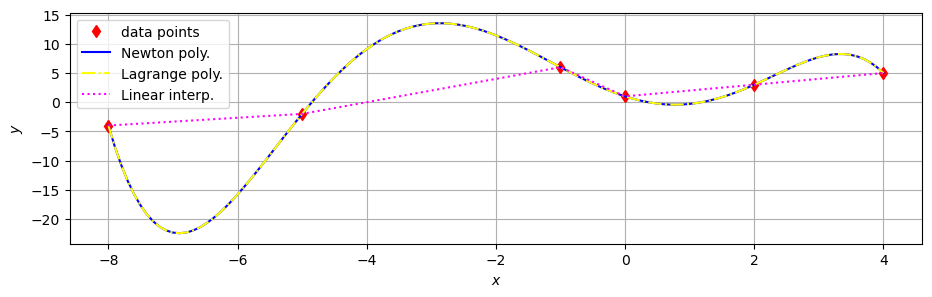

In [21]:
# Plotting the result

plt.figure(figsize=(11,3))

plt.plot(x, y, marker = "d", color = "red", linestyle = " "\
        , label = "data points")
plt.plot(x_new1, y_new1, color = "blue", linestyle = "-"\
        , label ="Newton poly.")
plt.plot(x_new1, y_new2, color = "yellow", linestyle = "-."\
        , label ="Lagrange poly.")
plt.plot(x_new1, y_new3, color = "magenta", linestyle = ":"\
        , label ="Linear interp.")

plt.grid()

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.legend()
plt.show()



### 4. Quadratic interpolation:


In [22]:
f_quadratic = interp.interp1d(x, y, kind = "quadratic")

y_new4 = f_quadratic(x_new1)

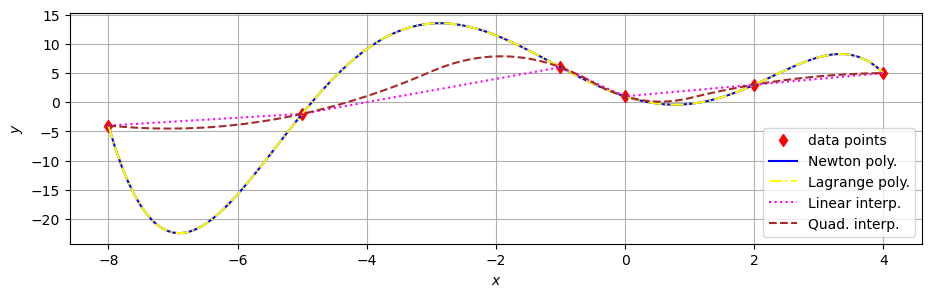

In [23]:
# Plotting the result

plt.figure(figsize=(11,3))

plt.plot(x, y, marker = "d", color = "red", linestyle = " "\
        , label = "data points")
plt.plot(x_new1, y_new1, color = "blue", linestyle = "-"\
        , label ="Newton poly.")
plt.plot(x_new1, y_new2, color = "yellow", linestyle = "-."\
        , label ="Lagrange poly.")
plt.plot(x_new1, y_new3, color = "magenta", linestyle = ":"\
        , label ="Linear interp.")
plt.plot(x_new1, y_new4, color = "brown", linestyle = "--"\
        , label ="Quad. interp.")

plt.grid()

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.legend()
plt.show()



### 5. Point-to-point Spline interpolation with interpolate.splrep() and interpolate.splev()

Both function are needed as they work together. The first one gets the B-spline representation as a **tck** tuple, and the second one uses such tuple to evaluate the splines.

#### Please read the documentation for more details:

https://en.wikipedia.org/wiki/B-spline

https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splrep.html#scipy.interpolate.splrep

https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splev.html#scipy.interpolate.splev

In [43]:
# First we call splrep

tck = interp.splrep(x, y, s=0, k=1)

print(len(tck))

#print(tck)
print("knots:", tck[0])
print("coefs:", tck[1])
print("k (degree):", tck[2])

3
knots: [-8. -8. -5. -1.  0.  2.  4.  4.]
coefs: [-4. -2.  6.  1.  3.  5.  0.  0.]
k (degree): 1


In [41]:
# Call the splev function to get the splines

y_new5 = interp.splev(x_new1, tck, der = 0)

print(x_new1.shape, y_new5.shape)

(121,) (121,)


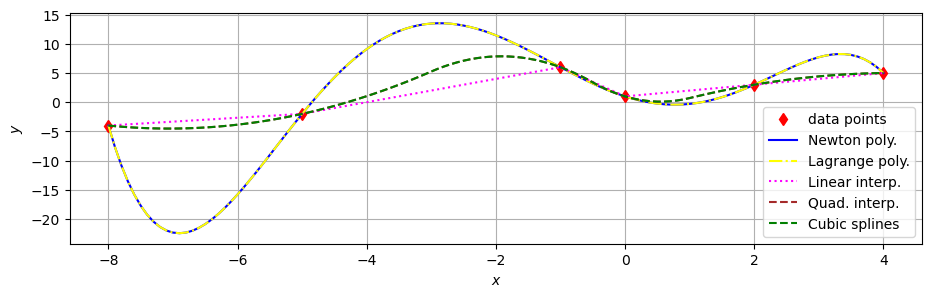

In [42]:
# Plotting the result

plt.figure(figsize=(11,3))

plt.plot(x, y, marker = "d", color = "red", linestyle = " "\
        , label = "data points")
plt.plot(x_new1, y_new1, color = "blue", linestyle = "-"\
        , label ="Newton poly.")
plt.plot(x_new1, y_new2, color = "yellow", linestyle = "-."\
        , label ="Lagrange poly.")
plt.plot(x_new1, y_new3, color = "magenta", linestyle = ":"\
        , label ="Linear interp.")
plt.plot(x_new1, y_new4, color = "brown", linestyle = "--"\
        , label ="Quad. interp.")

plt.plot(x_new1, y_new5, color = "green", linestyle = "--"\
        , label ="Cubic splines")

plt.grid()

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.legend()
plt.show()



### How to get the B-splines functions out?

In [46]:
# Let's create two vectors

a = np.array([1., 2., 3.])

b = np.array([9., 10., 1.])

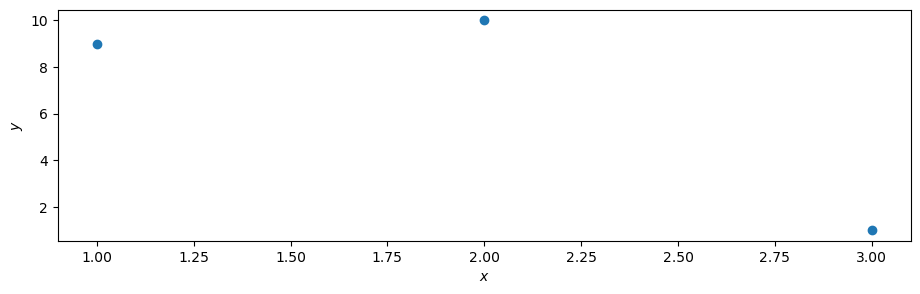

In [47]:
# Plotting 

plt.figure(figsize=(11,3))

plt.plot(a, b, marker = "o", linestyle = " ")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.show()

In [48]:
# First we need to call splrep()

tck_ab = interp.splrep(a, b, s=0, k=1)

print("knots:", tck_ab[0])
print("coefs:", tck_ab[1])
print("k (degree):", tck_ab[2])

# Second we call splev()

a_new = np.arange(1., 3.1, 0.1)

b_new = interp.splev(a_new, tck_ab, der = 0)

knots: [1. 1. 2. 3. 3.]
coefs: [ 9. 10.  1.  0.  0.]
k (degree): 1


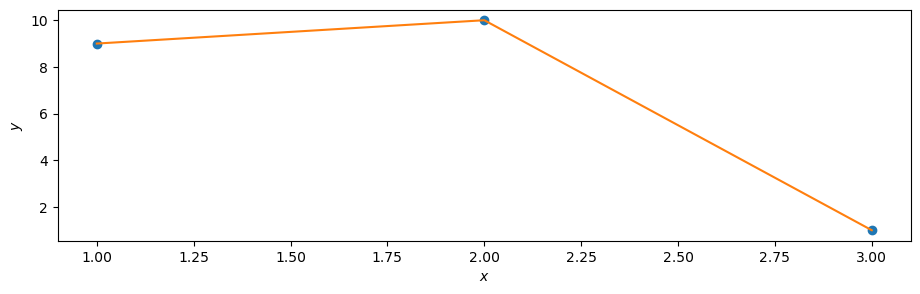

In [50]:
# Plotting 

plt.figure(figsize=(11,3))

plt.plot(a, b, marker = "o", linestyle = " ")
plt.plot(a_new, b_new, linestyle = "-" )

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.show()

In [53]:
# Evaluate using PPoly.from_spline()

pf = interp.PPoly.from_spline(tck_ab)

print(pf.c)

#print(pf.x)

[[ 1.  1. -9. -9.]
 [ 9.  9. 10.  1.]]


In [54]:
# Piece-wise polynomial # 1:

p_0 = lambda x: pf.c[0,0]*(x - pf.x[0]) + pf.c[1,0]

p_1 = lambda x: pf.c[0,2]*(x - pf.x[2]) + pf.c[1,2]

# Evaluate this in our axis:

f_0 = p_0(a_new)
f_1 = p_1(a_new)

print("p_1(x) = " + str(pf.c[0,0]) + " (x - " + str(pf.x[0]) + ") + " + str(pf.c[1,0]))
print("p_2(x) = " + str(pf.c[0,2]) +  " (x - " + str(pf.x[2]) + ") + " + str(pf.c[1,2]))

p_1(x) = 1.0 (x - 1.0) + 9.0
p_2(x) = -9.0 (x - 2.0) + 10.0


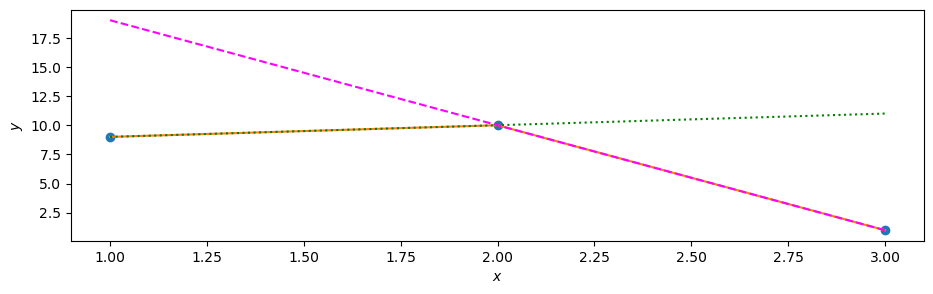

In [55]:
# Plotting 

plt.figure(figsize=(11,3))

plt.plot(a, b, marker = "o", linestyle = " ")
plt.plot(a_new, b_new, linestyle = "-" )

plt.plot(a_new, f_0, linestyle = ":", color = "green")
plt.plot(a_new, f_1, linestyle = "--", color = "magenta")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.show()

# Example:

Time series of mean temperature in Ibarra:

https://github.com/wbandabarragan/computational-physics-1/blob/main/sample-data/temperature_data.csv


- The data correspond to time in months versus average (mean) temperature in Ibarra.


- Time period is 3 years.


Carry out interpolation to increase the resolution and/or fill in the gaps in the time series.

In [1]:
!head ./temperature_data.csv
!tail ./temperature_data.csv

Month,Mean_temperature(C)
1,17.1
2,17.7
3,17.4
4,17.8
5,18.4
6,18.8
7,18.7
8,18.6
9,18.5
28,17.9
29,17.8
30,18.2
31,18.1
32,18.7
33,18.8
34,18.2
35,17.9
36,17.5



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Import the data:

data_temp = pd.read_csv("./temperature_data.csv")

#print(data_temp)

# Place data into arrays

month = np.array(data_temp["Month"])
temp  = np.array(data_temp["Mean_temperature(C)"])

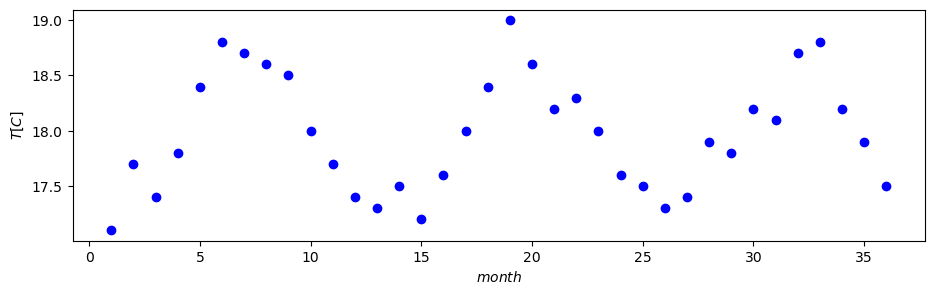

In [10]:
# Plotting
plt.figure(figsize=(11,3))

plt.plot(month, temp, linestyle = " ", marker = "o", color = "blue")
#plt.plot(month, temp, linestyle = "--", marker = "o", alpha = 0.2, color = "blue")

plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.show()


In [11]:
print(len(month))

36


#### Interpolation:

In [15]:
# Interpolation functions

f_1 = interp.interp1d(month, temp, kind = "linear")
f_2 = interp.interp1d(month, temp, kind = "quadratic")

f_3 = interp.interp1d(month, temp, kind = "nearest")
f_4 = interp.interp1d(month, temp, kind = "previous")
f_5 = interp.interp1d(month, temp, kind = "next")

#print(f_1)


In [16]:
# Evaluate the above into an axis:

month_new = np.arange(1., 36.25, 0.25)

#print(month_new)

temp_1 = f_1(month_new)
temp_2 = f_2(month_new)
temp_3 = f_3(month_new)
temp_4 = f_4(month_new)
temp_5 = f_5(month_new)

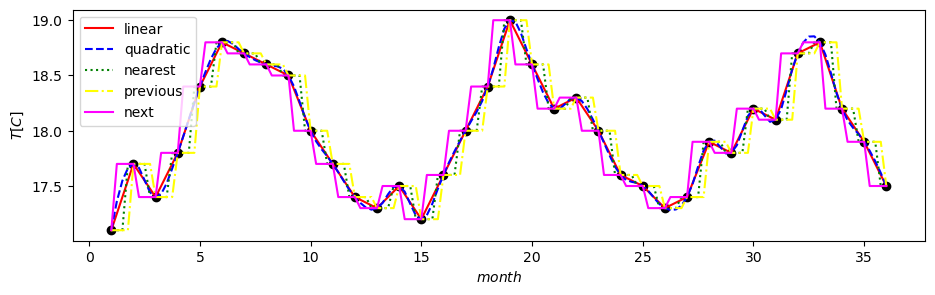

In [21]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(month, temp, linestyle = " ", marker = "o", color = "black")
plt.plot(month_new, temp_1, linestyle = "-", label = "linear", 
       color = "red")
plt.plot(month_new, temp_2, linestyle = "--", label = "quadratic",\
       color = "blue")
plt.plot(month_new, temp_3, linestyle = ":", label = "nearest",\
        color = "green")

plt.plot(month_new, temp_4, linestyle = "-.", label = "previous",\
       color = "yellow")
plt.plot(month_new, temp_5, linestyle = "-", label = "next",\
       color = "magenta")

plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.legend()

plt.show()


### Spline interpolation

In [22]:
# Get the tck object:

tck = interp.splrep(month, temp, s=0, k=3)

# Evalue the coefficients to get the Splines:

temp_spline = interp.splev(month_new, tck, der=0)

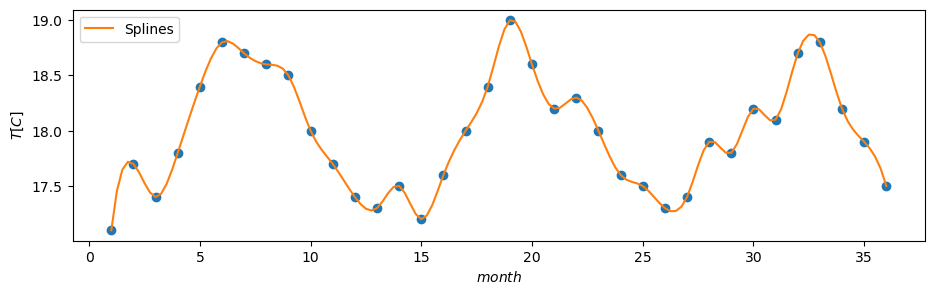

In [23]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(month, temp, linestyle = " ", marker = "o")

plt.plot(month_new, temp_spline, linestyle = "-", label="Splines")

plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.legend()

plt.show()


## Example 2: Filling in missing data

https://github.com/wbandabarragan/computational-physics-1/blob/main/sample-data/temperature_data_missing.csv

In [24]:
# Import the data:

data_missing = pd.read_csv("./temperature_data_missing.csv")

#print(data_missing)

# Place data into arrays

month_missing = np.array(data_missing["Month"])
temp_missing  = np.array(data_missing["Mean_temperature(C)"])

In [25]:
print(temp_missing)

[17.1 17.7 17.4 17.8 18.4 18.8 18.7 18.6 18.5 18.  17.7 17.4 17.3 17.5
 17.2 17.6 18.  18.4 19.  18.6 18.2 18.3 18.  17.6  nan  nan  nan  nan
 17.8 18.2 18.1 18.7 18.8 18.2 17.9 17.2 17.3 17.4 17.9 18.  18.1 18.3
 18.4 18.4 17.9 17.7 17.2 17.3 17.4 17.5 17.5  nan  nan  nan  nan  nan
  nan 17.8 17.6 17.3 17.1 17.  17.2 17.3 17.5 17.9 18.  18.3 18.8 18.5
 17.9 17.1]


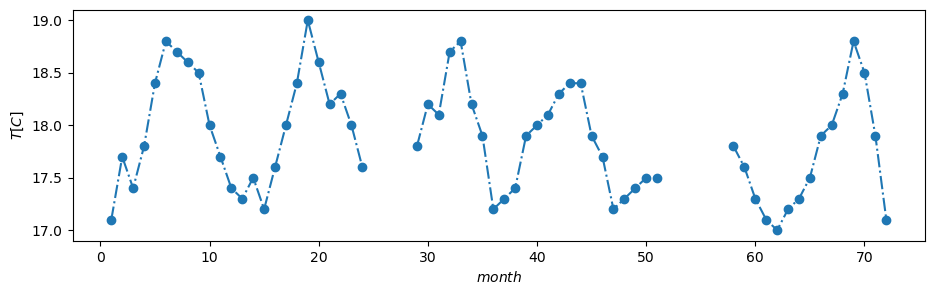

In [26]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(month_missing, temp_missing, linestyle = "-.", marker = "o")

plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.show()

In [27]:
# New axis:
month_new1 = np.arange(1, 72.25, 0.25)

In [28]:
# Interpolator:

f_interp_missing = interp.interp1d(month_missing, temp_missing, \
                                  kind = "cubic")

# Evaluate:

temp_missing1 = f_interp_missing(month_new1)

print(temp_missing1)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan na

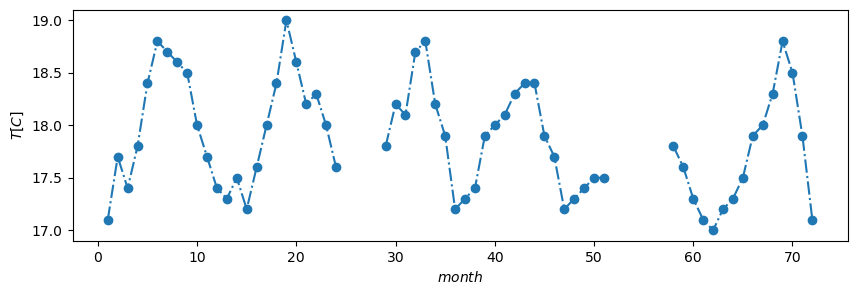

In [29]:
# Plotting

plt.figure(figsize=(10,3))

plt.plot(month_missing, temp_missing, linestyle = "-.", marker = "o")
plt.plot(month_new1, temp_missing1, linestyle = "-")

plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.show()

### Basic analysis with NANs:



In [30]:
# Mean values

mean_temp = np.mean(temp_missing)
print(mean_temp)

mean_temp = np.nanmean(temp_missing)
print(mean_temp)


# Std. Dev. values

std_temp = np.std(temp_missing)
print(std_temp)

std_temp = np.nanstd(temp_missing)
print(std_temp)

nan
17.875806451612902
nan
0.5238460386568187


#### NAN clean up:


In [31]:
print(temp_missing)

[17.1 17.7 17.4 17.8 18.4 18.8 18.7 18.6 18.5 18.  17.7 17.4 17.3 17.5
 17.2 17.6 18.  18.4 19.  18.6 18.2 18.3 18.  17.6  nan  nan  nan  nan
 17.8 18.2 18.1 18.7 18.8 18.2 17.9 17.2 17.3 17.4 17.9 18.  18.1 18.3
 18.4 18.4 17.9 17.7 17.2 17.3 17.4 17.5 17.5  nan  nan  nan  nan  nan
  nan 17.8 17.6 17.3 17.1 17.  17.2 17.3 17.5 17.9 18.  18.3 18.8 18.5
 17.9 17.1]


In [32]:
# Get the indices for all the finite values

idx_finite = np.isfinite(temp_missing)

print(idx_finite)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False False False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False False False False False False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]


In [33]:
print(month_missing.shape, temp_missing.shape)

(72,) (72,)


In [34]:
# Get the clean vectors

month_cleaned = month_missing[idx_finite]
temp_cleaned  = temp_missing[idx_finite]

print(month_cleaned.shape, temp_cleaned.shape)

(62,) (62,)


In [35]:
print(np.unique(temp_missing))
print(np.unique(temp_cleaned))

[17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3
 18.4 18.5 18.6 18.7 18.8 19.   nan]
[17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3
 18.4 18.5 18.6 18.7 18.8 19. ]


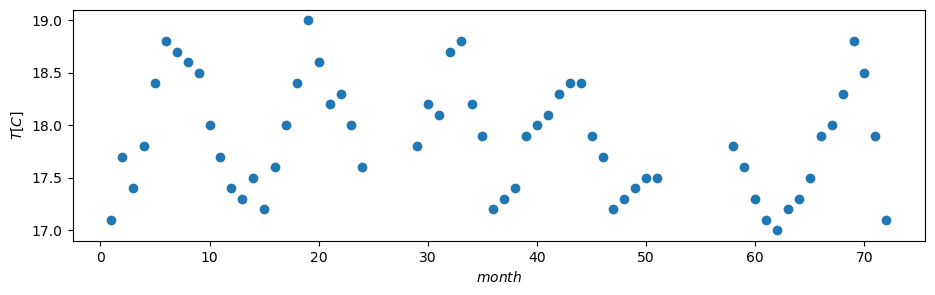

In [37]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(month_cleaned, temp_cleaned , linestyle = " ", marker = "o")

plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.show()

### Interpolation over the cleaned data:

In [38]:
# Interpolator:

f_interp_cleaned = interp.interp1d(month_cleaned, temp_cleaned, \
                                  kind = "cubic")

f_interp_cleaned2 = interp.interp1d(month_cleaned, temp_cleaned, \
                                  kind = "linear")

# Evaluate:

temp_cleaned1 = f_interp_cleaned(month_new1)
temp_cleaned2 = f_interp_cleaned2(month_new1)

print(temp_cleaned1)

[17.1        17.45318321 17.64828081 17.71923801 17.7        17.62451199
 17.52671919 17.44056679 17.4        17.43001881 17.51984242 17.64974482
 17.8        17.95385025 18.10641111 18.25576641 18.4        18.53583018
 18.65451313 18.74593952 18.8        18.81064154 18.78803636 18.746413
 18.7        18.66066617 18.63084142 18.61059597 18.6        18.5966938
 18.58859795 18.56120313 18.5        18.39630864 18.26476676 18.1258415
 18.         17.90244666 17.827335   17.76355585 17.7        17.62827974
 17.55089323 17.4730601  17.4        17.33755939 17.29409209 17.27857874
 17.3        17.3605452  17.43523841 17.49231243 17.5        17.43900983
 17.33995425 17.24592156 17.2        17.2334155  17.32994457 17.46150135
 17.6        17.72264066 17.82776746 17.91901054 18.         18.07602185
 18.15898557 18.2624565  18.4        18.57639693 18.76129025 18.91553845
 19.         18.98714043 18.89585343 18.75663971 18.6        18.45316634
 18.33029605 18.24227772 18.2        18.20800669 18.245

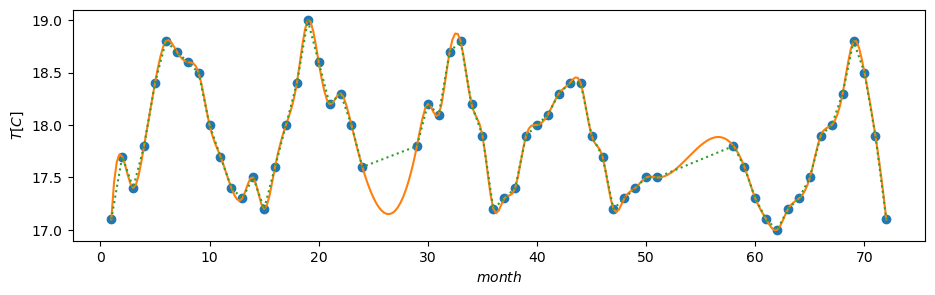

In [39]:
# Plotting

plt.figure(figsize=(11,3))

plt.plot(month_cleaned, temp_cleaned , linestyle = " ", marker = "o")
plt.plot(month_new1, temp_cleaned1, linestyle = "-")
plt.plot(month_new1, temp_cleaned2, linestyle = ":")


plt.xlabel(r"$month$")
plt.ylabel(r"$T[C]$")

plt.show()